<a href="https://colab.research.google.com/github/macontreras04/cpf/blob/main/Exam2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Examn 2

Candidate CQF: Miguel Contreras \
Country: Mexico \
Cohort: JANUARY 2026


In [ ]:
import numpy as np
from numpy.random import randn
import matplotlib.pyplot as plt
from scipy import stats

## Mathematical framework

The Black-Scholes model assumes the stock price $S_{t}$ evolves in time according to the following stochastic differential equation (SDE):

$$dS_{t} = \mu S_{t}  dt +  \sigma S dW_{t}$$

where $dW_{t}$ is a standard Brownian motion, which means that is normal distributed $N(0,1)$.


# Monte Carlo simulation


1. Random Numbers

## Congruentional methos, Twister Mennser and Box-Muller Method.

Monte Carlo simulation is a technique very common on option pricing since is easy to implement and very intuitive. MC techniques are very vast both all verision leverage from the discretization of SDE. Among the popular methods of discretization is Euler scheme or Eurler-Maruyama scheme. The second thta is becomen very popular is the Milstein scheme, because of the second term on the SDE.


Monte Carlo technique was developed during the second World War on the Manhatan project. Now we will discuss two importanta algorithms to generate pseudo- random numbers...


# Euler-Maruyama Scheme

This methods uses discretization from a SDE to solving using Monte Carlo simulation. According to the non-arbitrage theory, we can change the SDE from the real probability measure $\mathbb{P}$ to $\mathbb{Q}$ making that $\mu$ is set equal to the risk-free rate $r$, associate to a risk-free instrument, typically a zero coupon bond. Therefore, the SDE under the real probability measure change as follows:

$$dS_{t} = \mu S_{t}  dt +  \sigma S_{t} dW^{\mathbb{P}} _{t}$$


Replacing $\mu$ by $r$


$$dS_{t} = r S_{t}  dt +  \sigma S_{t} dW^{\mathbb{Q}} _{t}$$

## Change of measure

As we saw on the lectures, it is possible using the right transformartion make a change of measure so the SDE above could become in a martingale. I f we compute the expectation replacing $S_{t}$ by the discounted price $S^{*}_{t}= S e^{-r(T-t) }$

$$dS^{*}_{t} = r S^{*}_{t}  dt +  \sigma S^{*} dW _{t}$$

X

$$d(S e^{-r(T-t)}) = (dS_{t})e^{-r(T-t)} - S_{t} r e^{-r(T-t)}$$

Now if we substitute $dS_{t}$:

$$d(S e^{-r(T-t)}) = ( r S_{t}  dt +  \sigma S dW) e^{-r(T-t)} - S_{t} r e^{-r(T-t)}$$


$$d(S e^{-r(T-t)}) = ( r S_{t} e^{-r(T-t)}  dt - S_{t} r e^{-r(T-t)} +  \sigma S_{t}  e^{-r(T-t)} dW)$$


$$dS^{*}_{t}  =  \sigma S^{*} dW _{t}$$

The equation above is driftless and hece a martingale. Consequently, $E[S_{t} e^{-r(T-t)} ] = S_{0}.$


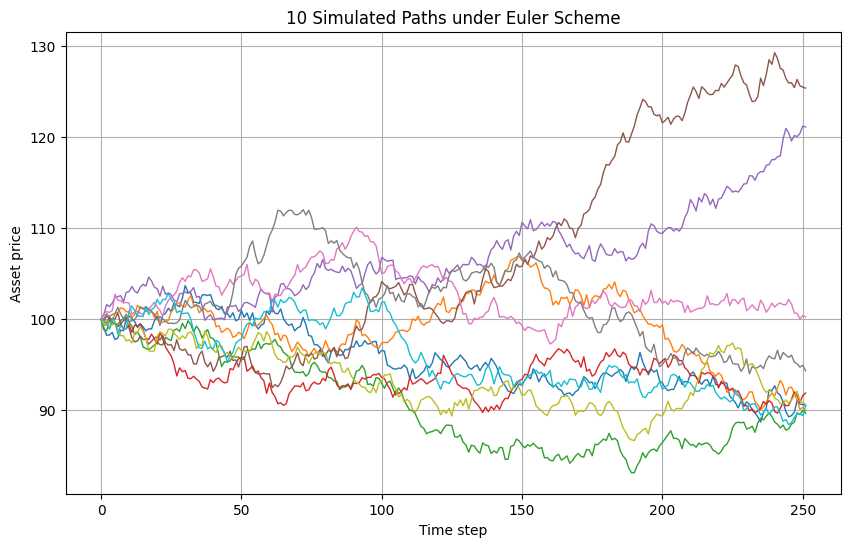

In [ ]:
# Simulation under Euler scheme

n=10 # number of paths

m=252 # number of time-steps

dt= 1/252 # the time-step lenght is one business day

S0 = 100* np.ones(n)

S=np.zeros((m,n))

S[0, :] = S0

mu = 0.03

sigma = 0.1

# Random shocks
z = np.random.randn(m, n)


for j in range(0,n):
    for i in range(1,m):
        S[i,j] = S[i-1,j]*(1+ mu*dt + sigma*np.sqrt(dt)* z[i,j])

# Time axis
t = np.arange(m)

# Plot
plt.figure(figsize=(10, 6))
for j in range(n):
    plt.plot(t, S[:, j], linewidth=1)

plt.title("10 Simulated Paths under Euler Scheme")
plt.xlabel("Time step")
plt.ylabel("Asset price")
plt.grid(True)
plt.show()



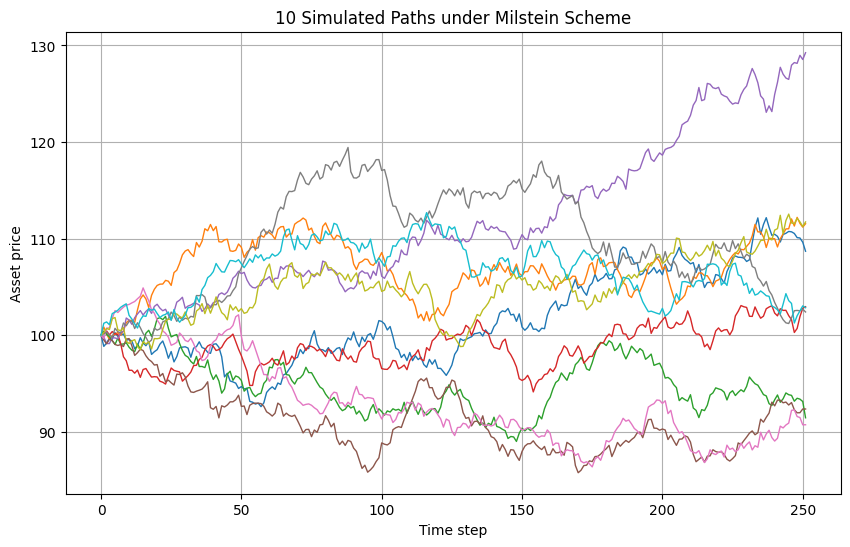

In [ ]:
# Simulation under Milstein scheme

n=10 # number of paths

m=252 # number of time-steps

dt= 1/252 # the time-step lenght is one business day

S0 = 100* np.ones(n)

S=np.zeros((m,n))

S[0, :] = S0

mu = 0.03

sigma = 0.1

# Random shocks
z = np.random.randn(m, n)


for j in range(0,n):
    for i in range(1,m):
        S[i,j] = S[i-1,j]*(1+ mu*dt + sigma*np.sqrt(dt)* z[i,j]) + (sigma**2)*((np.sqrt(dt)* z[i,j])**2-dt)

# Time axis
t = np.arange(m)

# Plot
plt.figure(figsize=(10, 6))
for j in range(n):
    plt.plot(t, S[:, j], linewidth=1)

plt.title("10 Simulated Paths under Milstein Scheme")
plt.xlabel("Time step")
plt.ylabel("Asset price")
plt.grid(True)
plt.show()

